Please upload the 'marketing_campaign.csv' file from Kaggle:


Saving marketing_campaign.csv to marketing_campaign.csv


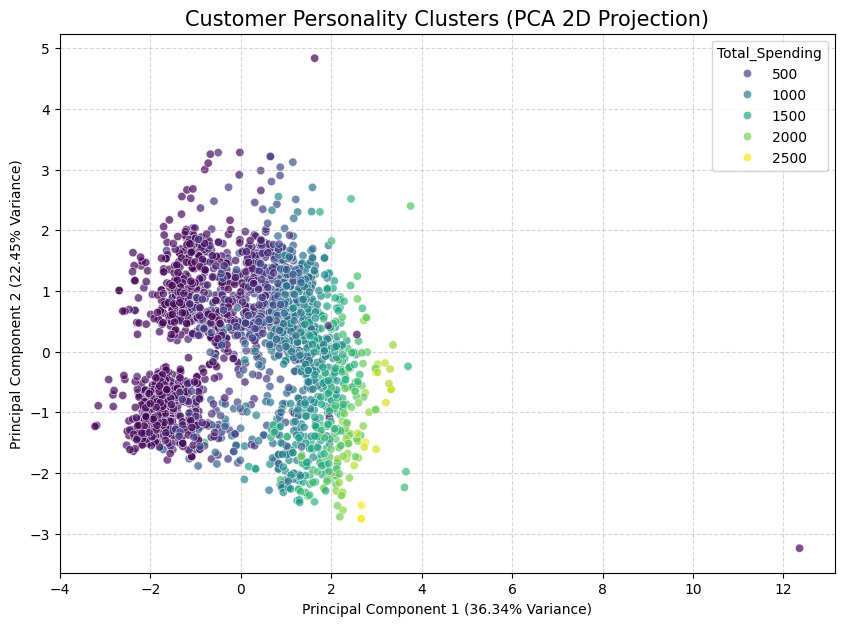

Total Variance Explained by 2 components: 58.79%


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from google.colab import files

# --- 1. UPLOAD DATASET ---
print("Please upload the 'marketing_campaign.csv' file from Kaggle:")
uploaded = files.upload()

# --- 2. LOAD & CLEAN DATA ---
# This dataset uses tabs (\t) as separators
df = pd.read_csv('marketing_campaign.csv', sep="\t")

# Basic Cleaning
df = df.dropna() # Removing rows with missing Income
df['Total_Spending'] = df[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum(axis=1)
df['Age'] = 2026 - df['Year_Birth'] # Updated for current year

# Selecting relevant numerical features for PCA
features = ['Age', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'Total_Spending']
X = df[features]

# --- 3. PRE-PROCESSING ---
# PCA is highly sensitive to scale, so StandardScaler is mandatory
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# --- 4. APPLY PCA ---
# We reduce the dimensions to 2 for visualization
pca = PCA(n_components=2)
pca_data = pca.fit_transform(X_scaled)

# Create a new DataFrame for the PCA results
pca_df = pd.DataFrame(data=pca_data, columns=['PC1', 'PC2'])
pca_df['Total_Spending'] = df['Total_Spending'].values # Adding back for color coding

# --- 5. VISUALIZATION ---
plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='PC1',
    y='PC2',
    hue='Total_Spending',
    palette='viridis',
    data=pca_df,
    alpha=0.7
)

plt.title('Customer Personality Clusters (PCA 2D Projection)', fontsize=15)
plt.xlabel(f'Principal Component 1 ({pca.explained_variance_ratio_[0]*100:.2f}% Variance)')
plt.ylabel(f'Principal Component 2 ({pca.explained_variance_ratio_[1]*100:.2f}% Variance)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

# --- 6. ACCURACY/VARIANCE CHECK ---
print(f"Total Variance Explained by 2 components: {sum(pca.explained_variance_ratio_) * 100:.2f}%")